# Introduction to sf: Reading, Writing, and Inspecting Vector Data
### by [Kate Vavra-Musser](https://vavramusser.github.io) for the [R Spatial Notebook Series](https://vavramusser.github.io/r-spatial)

## Introduction

The [***sf***](https://cran.r-project.org/web/packages/sf/index.html) R package was designed to provide support for working with the [simple features (sf)](https://r-spatial.github.io/sf/articles/sf1.html) standard for geographic [vector data](https://en.wikipedia.org/wiki/Vector_graphics) representation within the R ecosystem.  The *sf* package was first released in 2016 and within a few years had largely surpassed the [***sp***](https://cran.r-project.org/web/packages/sp/index.html) package (first released in 2005) as the most commonly used geographic data representation for vector data in R.  In additon to providing support for the simple features data standard, *sf* includes a wide range of functions for working with spatial vector data in R.  If you are accustomed to working with spatial data using traditional [GIS](https://en.wikipedia.org/wiki/Geographic_information_system) desktop software such as [QGIS](https://en.wikipedia.org/wiki/QGIS) or [ArCGIS](https://en.wikipedia.org/wiki/ArcGIS), you will find analogues to the typical analysis, query, selection, geoprocessing, and visualization GIS tools within the *sf* package.

#### From the [Simple Features for R](https://r-spatial.github.io/sf/articles/sf1.html) Webpage
*[Simple features (sf)](https://en.wikipedia.org/wiki/Simple_Features) or [simple feature access](https://www.ogc.org/publications/standard/sfa) refers to a formal standard ([ISO 19125-1:2004](https://www.iso.org/standard/40114.html)) that describes how objects in the real world can be represented in computers, with emphasis on the spatial geometry of these objects. It also describes how such objects can be stored in and retrieved from databases, and which geometrical operations should be defined for them.  The standard is widely implemented in spatial databases (such as [PostGIS](https://postgis.net)), commercial GIS (e.g., [ESRI ArcGIS](https://www.esri.com/en-us/home)) and forms the vector data basis for libraries such as [GDAL](https://gdal.org/en/stable).*

### Notebook Goals
This notebook will introduce you to the [***sf***](https://cran.r-project.org/web/packages/sf/index.html) package and working with geographic vector data in the [simple features (sf)](https://en.wikipedia.org/wiki/Simple_Features) data standard.  This notebook is only intended to be a very quick introductin to the *sf* package as many more *sf* functions will be introduced in later notebooks, primairly in the **Mapping and Visualization** and **Spatial Analyses** chapters.

### 💽 Data Used in this Notebook 💽
* Have a copy of United States Boundary Shapefile (*usa_boundary.shp*) file available in your workspace
  * You can download a copy of *usa_boundary.zip* file from [the I-GUIDE platform](https://platform.i-guide.io/datasets/aae279db-71f0-47e4-91e7-e8ac8791ea56) or directly from [Kate's GitHub](https://github.com/vavramusser/r-spatial/blob/main/usa_boundary.zip).  You will need to unzip *usa_boundary.zip* and extract *usa_boundary.shp* file to your workspace.

### Additional Resources on the Web

* [Using *sf* for Spatial Data & Intro to Making Maps](https://learning.nceas.ucsb.edu/2023-04-coreR/session_15.html)

### Notebook Overview
1. Setup
2. Reading and Writing Spatial Data
4. Creating and Viewing Spatial Objects

---

## 1. Setup
This notebook requires the following R packages and functions.

[**sf**](https://cran.r-project.org/web/packages/sf/index.html) · Support for [simple features](https://r-spatial.github.io/sf/articles/sf1.html), a standardized way to encode spatial vector data - Binds to [GDAL](https://gdal.org/en/stable) for reading and writing data, to [GEOS](https://libgeos.org) for geometrical operations, and to [PROJ](https://proj.org/en/stable) for projection conversions and datum transformations - Uses by default the [*s2*](https://cran.r-project.org/web/packages/s2/index.html) package for spherical geometry operations on ellipsoidal (long/lat) coordinates · This notebook uses the following functions from *sf*.

* [*st_as_sf*](https://rdrr.io/cran/sf/man/st_as_sf.html) · convert foreign object to an sf object
* [*st_bbox*](https://rdrr.io/cran/sf/man/st_bbox.html) · return bounding of a simple feature or simple feature set
* [*st_geometry*](https://rdrr.io/cran/sf/man/st_geometry.html) · get, set, replace or rename geometry from an sf object
* [*st_read*](https://rdrr.io/cran/sf/man/st_read.html) · read simple features or layers from file or database
* [*st_write*](https://rdrr.io/cran/sf/man/st_write.html) · write simple features object to file or database

### 1a. Install and Load Required Packages

If you have not already installed the required packages, uncomment and run the code below:

In [1]:
# install.packages("sf")

Load the packages into your workspace.

In [2]:
library(sf)

Linking to GEOS 3.10.2, GDAL 3.4.1, PROJ 7.2.1; sf_use_s2() is TRUE



## 2. Reading and Writing Spatial Data

### 2a. Reading Spatial Data with [`st_read`](https://rdrr.io/cran/sf/man/st_read.html)

The [`st_read`](https://rdrr.io/cran/sf/man/st_read.html) function from the [***sf***](https://cran.r-project.org/web/packages/sf/index.html) package reads spatial vector data from a variety of formats supported by [GDAL (Geospatial Data Abstraction Library)](https://gdal.org/en/stable), including [ESRI Shapefile (.shp)](https://doc.arcgis.com/en/arcgis-online/reference/shapefiles.htm), [GeoJSON (.geojson)](https://geojson.org), [GeoPackage (.gpkg)](https://www.geopackage.org), [KML (.kml) and KMZ (.kmz)](https://en.wikipedia.org/wiki/Keyhole_Markup_Language), [CSV with WKT (well-known text) (.csv)](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry), and more.

[`st_read`](https://rdrr.io/cran/sf/man/st_read.html) simplifies the process of reading in spatial data by automatically recognizing the file format and returning the data as a [simple features (sf)](https://en.wikipedia.org/wiki/Simple_Features) object.

**★ Pro Tip:**  If the [coordinate reference system (CRS)](https://en.wikipedia.org/wiki/Spatial_reference_system) is specified in the file, it will be read automatically.

In [3]:
# read the USA boundary shapefile as an sf object
usa_boundary <- st_read("Chapter 2 Data/usa_boundary.shp")

Reading layer `usa_boundary' from data source 
  `C:\Users\vavra\Dropbox\R Spatial\r-spatial\02 Fundamentals of Spatial Data\Chapter 2 Data\usa_boundary.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 166 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -171.7911 ymin: 18.91619 xmax: -66.96466 ymax: 71.35776
Geodetic CRS:  WGS 84


When we use [`st_read`](https://rdrr.io/cran/sf/man/st_read.html) to read in the *usa_boundary.shp* shapefile we get a preview of some of the file's spatial metadata.

* The data was read in using the **ESRI Shapefile** driver.
* The data includes **1 feature** (the boundary of the United States) and has **166 attribute fields**.
* The geometry type is **multipolygon**.
* The bounding box is **(-171.7911, 18.9161) (-66.96466 71.35776)**
* The coordinate reference system (CRS) is the **[World Geodetic System 1984 (WGS 84)](https://en.wikipedia.org/wiki/World_Geodetic_System) CRS**

### 2b. Writing Spatial Data with [*st_write*](https://rdrr.io/cran/sf/man/st_write.html)

To export spatial data, the `st_write()` function can save an *sf* object to a variety of formats.

You can specify the output format by either adding the appropriate file extension or specifying the appropritate GDAL driver.  Additional options can be specified to control how the data is written.

For example, the following two lines of code achieve the same output.

**★ Pro Tip:**  The `append = F` parameter allows the file to overwrite an already-existing file with the same name in the working directory.

In [4]:
st_write(usa_boundary, "Chapter 2 Data/usa_boundary.shp", append = F)
st_write(usa_boundary, "Chapter 2 Data/usa_boundary", driver = "ESRI Shapefile", append = F)

Deleting layer `usa_boundary' using driver `ESRI Shapefile'
Writing layer `usa_boundary' to data source 
  `Chapter 2 Data/usa_boundary.shp' using driver `ESRI Shapefile'
Writing 1 features with 166 fields and geometry type Multi Polygon.
Writing layer `usa_boundary' to data source 
  `Chapter 2 Data/usa_boundary' using driver `ESRI Shapefile'
Writing 1 features with 166 fields and geometry type Multi Polygon.


### 2c. Spatial Data Types Supported by the `st_read` and `st_write` Functions

| **Format Name**          | **File Extension** | **GDAL Driver**         | **Description** | **Commonality Ranking** |
|:--------------------------|:-------------------|:-------------------------|:----------------|:------------------------|
| **GeoPackage**           | `.gpkg`           | `GPKG`                  | Modern SQLite-based format, supports multiple layers and large datasets efficiently. | ✅ **Very Common** |
| **ESRI Shapefile**       | `.shp`            | `ESRI Shapefile`        | Legacy GIS format, widely supported but has limitations (e.g., 10-character field names, no multi-layer support). | ✅ **Very Common** |
| **GeoJSON**              | `.geojson`        | `GeoJSON`               | Lightweight JSON-based format used in web mapping applications. | ✅ **Very Common** |
| **CSV with WKT/WKB**     | `.csv`            | `CSV`                    | Tabular format; stores spatial data as WKT (Well-Known Text) or coordinates in separate columns. | ✅ **Very Common** |
| **KML/KMZ**              | `.kml`, `.kmz`    | `KML`                   | Used in Google Earth and lightweight visualization applications. | ⚠️ **Less Common** |
| **FlatGeobuf**           | `.fgb`            | `FlatGeobuf`            | High-performance binary format, optimized for large datasets and streaming. | ⚠️ **Less Common** |
| **Spatialite (SQLite-based)** | `.sqlite` | `SQLite`                | Lightweight spatial database format similar to GeoPackage but less widely adopted. | ⚠️ **Less Common** |
| **MapInfo TAB**          | `.tab`            | `MapInfo File`          | Proprietary format used in MapInfo GIS software, mostly in government applications. | ⚠️ **Less Common** |
| **GML (Geography Markup Language)** | `.gml` | `GML`                   | XML-based open standard for spatial data, used in OGC services and European INSPIRE datasets. | ⚠️ **Less Common** |
| **PostGIS (Database)**   | N/A (Direct Connection) | `PostgreSQL/PostGIS` | Stores spatial data in a PostgreSQL database with advanced querying capabilities. | ⛔ **Specialized or Advanced Use** |
| **OpenStreetMap (OSM XML)** | `.osm`        | `OSM`                   | XML-based format containing OpenStreetMap data. | ⛔ **Specialized or Advanced Use** |
| **DXF (AutoCAD)**        | `.dxf`            | `DXF`                   | CAD format for exchanging vector data, used in engineering and design. | ⛔ **Specialized or Advanced Use** |
| **GPS Exchange Format (GPX)** | `.gpx`    | `GPX`                   | Format for storing GPS waypoints, routes, and tracks. | ⛔ **Specialized or Advanced Use** |
| **MapInfo Interchange**  | `.mif`, `.mid`    | `MapInfo File`          | ASCII-based MapInfo format for data exchange. | ⛔ **Specialized or Advanced Use** |

## 3. Creating and Viewing Spatial Objects

### 3a. Creating Simple Features with [*st_as_sf*](https://rdrr.io/cran/sf/man/st_as_sf.html)
The `st_as_sf()` function converts data frames with spatial information into *sf* objects.

* The `coords` argument specifies the column names for the x (longitude) and y (latitude) coordinates.
* The `crs` argument defines the coordinate reference system.

In [5]:
# sample data frame with coordinates
coordinates_df <- data.frame(
  id = 1:3,
  longitude = c(-93.625, -93.629, -93.635),
  latitude = c(42.034, 42.036, 42.040)
)

# view the sample data frame
print(coordinates_df)

  id longitude latitude
1  1   -93.625   42.034
2  2   -93.629   42.036
3  3   -93.635   42.040


In [6]:
# convert to sf object
points_sf <- st_as_sf(
  coordinates_df,
  coords = c("longitude", "latitude"),
  crs = 4326 # WGS84 CRS
)

# view the sf object
print(points_sf)

Simple feature collection with 3 features and 1 field
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -93.635 ymin: 42.034 xmax: -93.625 ymax: 42.04
Geodetic CRS:  WGS 84
  id               geometry
1  1 POINT (-93.625 42.034)
2  2 POINT (-93.629 42.036)
3  3  POINT (-93.635 42.04)


The data has been converted to an *sf* object with a *geometry* column.

### 3b. Viewing Spatial Extents with [*st_bbox*](https://rdrr.io/cran/sf/man/st_bbox.html)
The `st_bbox()` function extracts the bounding box (spatial extent) of an `sf` object.

In [7]:
# get the bounding box of the sf object
print(st_bbox(points_sf))

   xmin    ymin    xmax    ymax 
-93.635  42.034 -93.625  42.040 


### 3c. Accessing Geometries with [*st_geometry*](https://rdrr.io/cran/sf/man/st_geometry.html)
The `st_geometry()` function extracts the geometry (spatial features) of an `sf` object.

`st_geometry()` returns the geometry column as an `sfc` (simple feature column) object.  You can manipulate or analyze the geometry separately using additional `sf` functions.

In [8]:
# access geometry of an sf object
geometry <- st_geometry(points_sf)

# view geometry and spatial metadata
print(geometry)

Geometry set for 3 features 
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -93.635 ymin: 42.034 xmax: -93.625 ymax: 42.04
Geodetic CRS:  WGS 84


POINT (-93.625 42.034)

POINT (-93.629 42.036)

POINT (-93.635 42.04)



You can also pass the results of the `st_geometry` function to the `plot` function to create a quick map visualization of your data.

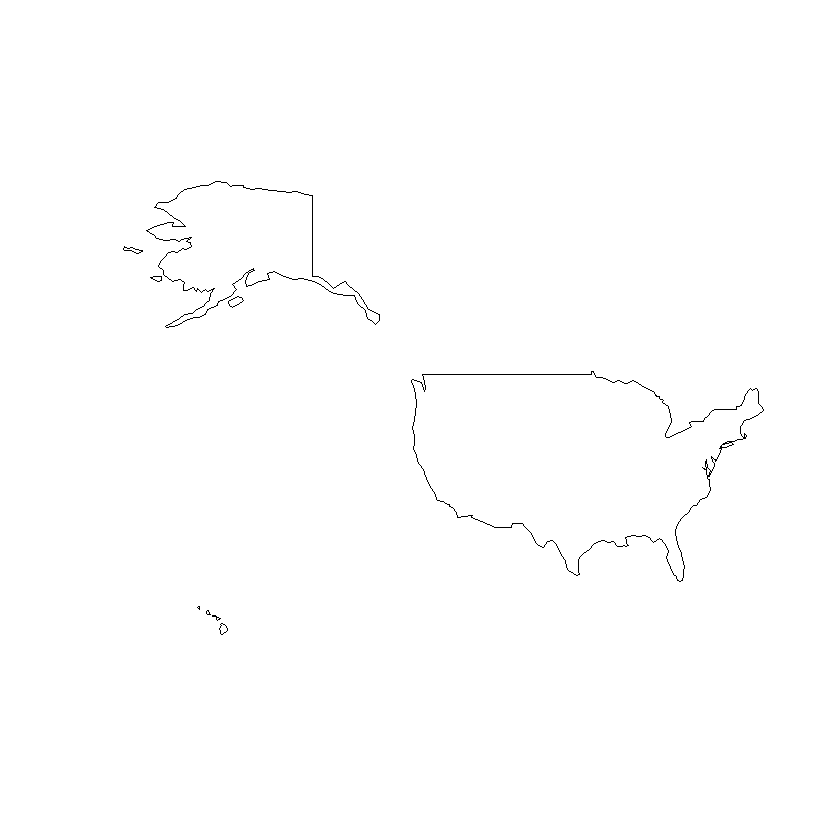

In [9]:
plot(st_geometry(usa_boundary))

## Review

This notebook provided an introduction to working with spatial data in R using the [*sf*](https://cran.r-project.org/web/packages/sf/index.html) package, including:

* Reading and writing spatial data with [*st_read*](https://rdrr.io/cran/sf/man/st_read.html) and [*st_write*](https://rdrr.io/cran/sf/man/st_write.html).
* Creating, inspecting, and manipulating spatial objects using [*st_as_sf*](https://rdrr.io/cran/sf/man/st_as_sf.html), [*st_bbox*](https://rdrr.io/cran/sf/man/st_bbox.html) , and [*st_geometry*](https://rdrr.io/cran/sf/man/st_geometry.html). 